# Temporal Dynamics: When Do Decision Signals Emerge?

## Research Questions

This notebook investigates **when** choice-related signals appear in physiology relative to response execution, using both PRE-decision (-2s to 0s) and POST-decision (0s to +2s) windows.

**Q1: Signal Emergence** — When do pupil, gaze, and EEG signals first diverge between INVEST and KEEP decisions?

**Q2: Cross-Modality Alignment** — Do modalities show synchronized or sequential divergence patterns? Literature suggests:
- Early divergence (-1.5s to -1.0s): Evidence accumulation phase
- Late divergence (-0.5s to 0s): Motor preparation + commitment consolidation

**Q3: Timing-Informed Classification** — Does selecting features from their optimal time bins improve accuracy over full-window averaging?

**Q4: Post-Decision Processing** — How do EEG signals differ between INVEST and KEEP in the review window (0s to +2s)?

## Literature Context

- **Centro-Parietal Positivity (CPP)**: EEG signal showing build-to-threshold ~300-800ms before response, tied to drift rate in DDM (Kelly & O'Connell, 2013)
- **Pupil dilation**: Peaks at decision commitment (not during deliberation), reflecting norepinephrine-mediated consolidation (Einhäuser et al., 2010)
- **Multimodal fusion**: 8-12% accuracy improvements when properly aligning EEG and eye tracking (Zheng et al., 2014)
- **Post-decision processing**: Error monitoring and confidence signals emerge in frontal EEG 200-500ms after response (Yeung et al., 2004)

In [21]:
import sys
sys.path.append('../..')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats, signal
from sklearn.impute import SimpleImputer
from tqdm import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.models.fusion import (
    weighted_late_fusion,
    weighted_late_fusion_train_optimal_bins,
)
from src.features.eeg_features import (
    FREQ_BANDS,
    CHANNEL_REGIONS,
    CHANNEL_NAMES,
    PREPROCESSED_EEG_PRE,
    PREPROCESSED_EEG_POST,
    EEG_EPOCH_T0,
    EEG_EPOCH_T1,
)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PREPROCESSING_DIR = Path('../../data/results/preprocessing')
OUTPUT_DIR = Path('../../data/results/main/statistical_analyses/temporal_dynamics')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"TEMPORAL DYNAMICS ANALYSIS")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

TEMPORAL DYNAMICS ANALYSIS
Analysis started: 2026-04-21 11:35:59


## 1. Configuration

In [22]:
# Time window settings
# PRE-decision window: stimulus onset to decision
PRE_WINDOW_START = -2.0  # seconds before submit
PRE_WINDOW_END = 0.0     # at submit

# POST-decision window: decision to feedback
POST_WINDOW_START = 0.0   # at submit
POST_WINDOW_END = 2.0     # seconds after submit

BIN_SIZE = 0.5  # 500ms bins

# Generate PRE-decision time bins
PRE_TIME_BINS = []
t = PRE_WINDOW_START
while t < PRE_WINDOW_END:
    PRE_TIME_BINS.append((t, min(t + BIN_SIZE, PRE_WINDOW_END)))
    t += BIN_SIZE

PRE_BIN_LABELS = [f"{tb[0]:.1f}s to {tb[1]:.1f}s" for tb in PRE_TIME_BINS]

# Generate POST-decision time bins
POST_TIME_BINS = []
t = POST_WINDOW_START
while t < POST_WINDOW_END:
    POST_TIME_BINS.append((t, min(t + BIN_SIZE, POST_WINDOW_END)))
    t += BIN_SIZE

POST_BIN_LABELS = [f"+{tb[0]:.1f}s to +{tb[1]:.1f}s" for tb in POST_TIME_BINS]

# Combined bins for full temporal analysis
ALL_TIME_BINS = PRE_TIME_BINS + POST_TIME_BINS
ALL_BIN_LABELS = PRE_BIN_LABELS + POST_BIN_LABELS

# Legacy compatibility
TIME_BINS = PRE_TIME_BINS
BIN_LABELS = PRE_BIN_LABELS

print(f"PRE-decision window: {PRE_WINDOW_START}s to {PRE_WINDOW_END}s")
print(f"POST-decision window: {POST_WINDOW_START}s to {POST_WINDOW_END}s")
print(f"Bin size: {BIN_SIZE}s")
print(f"\nPRE time bins: {PRE_BIN_LABELS}")
print(f"POST time bins: {POST_BIN_LABELS}")
print(f"\nEEG epoch constants: {EEG_EPOCH_T0}s to {EEG_EPOCH_T1}s")

BASELINE_METHOD = 't3_stable_pre_decision'
EEG_FS = 256  # EEG sampling rate

PRE-decision window: -2.0s to 0.0s
POST-decision window: 0.0s to 2.0s
Bin size: 0.5s

PRE time bins: ['-2.0s to -1.5s', '-1.5s to -1.0s', '-1.0s to -0.5s', '-0.5s to 0.0s']
POST time bins: ['+0.0s to +0.5s', '+0.5s to +1.0s', '+1.0s to +1.5s', '+1.5s to +2.0s']

EEG epoch constants: -2.0s to 0.0s


## 2. Load Data

In [23]:
# Load outcomes and pre-extracted features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']
physio_cols = feature_data['physio_cols']

outcome_lookup = dict(zip(merged_df['trial_id'], merged_df['outcome']))
print(f"Loaded outcomes for {len(outcome_lookup)} trials")

# Load raw JSON files for submit times (needed for gaze alignment)
RAW_DIR = Path('../../data/json')
raw_files = list(RAW_DIR.glob('*.json'))
print(f"Found {len(raw_files)} raw JSON files")

# Load continuous eye tracking data for gaze time-series
EYE_DIR = Path('../../data/eye')
eye_data_lookup = {}
for eye_file in EYE_DIR.glob('*.pkl'):
    subject_id = eye_file.stem
    with open(eye_file, 'rb') as f:
        eye_data_lookup[subject_id] = pickle.load(f)
print(f"Loaded eye tracking data for {len(eye_data_lookup)} subjects")

# Load PRE-decision EEG data (submit-locked, -2s to 0s)
# EEG shape is (n_channels, n_samples) = (20, 512) for 2-second epoch at 256 Hz
try:
    with open(PREPROCESSED_EEG_PRE, 'rb') as f:
        eeg_pre_df = pickle.load(f)

    # Verify EEG shape
    sample_eeg = eeg_pre_df.iloc[0]['eeg']
    print(f"\nPRE-decision EEG data shape per trial: {sample_eeg.shape}")
    print(f"  -> {sample_eeg.shape[0]} channels, {sample_eeg.shape[1]} samples")
    print(f"  -> {sample_eeg.shape[1] / EEG_FS:.1f}s epoch at {EEG_FS} Hz")

    # Build lookup: trial_id is 0-indexed in EEG
    eeg_pre_lookup = {}
    for _, row in eeg_pre_df.iterrows():
        trial_key = f"{row['trial_id']}_{row['subject_date_id']}"
        eeg_pre_lookup[trial_key] = row['eeg']

    print(f"Loaded PRE EEG for {len(eeg_pre_lookup)} trials ({eeg_pre_df['subject_date_id'].nunique()} subjects)")
    HAS_EEG_PRE = True
except FileNotFoundError:
    print("PRE-decision EEG data not available")
    eeg_pre_lookup = {}
    eeg_pre_df = pd.DataFrame()
    HAS_EEG_PRE = False

# Load POST-decision EEG data (submit-locked, 0s to +2s)
try:
    with open(PREPROCESSED_EEG_POST, 'rb') as f:
        eeg_post_df = pickle.load(f)

    sample_eeg_post = eeg_post_df.iloc[0]['eeg']
    print(f"\nPOST-decision EEG data shape per trial: {sample_eeg_post.shape}")
    print(f"  -> {sample_eeg_post.shape[0]} channels, {sample_eeg_post.shape[1]} samples")
    print(f"  -> {sample_eeg_post.shape[1] / EEG_FS:.1f}s epoch at {EEG_FS} Hz")

    # Build lookup
    eeg_post_lookup = {}
    for _, row in eeg_post_df.iterrows():
        trial_key = f"{row['trial_id']}_{row['subject_date_id']}"
        eeg_post_lookup[trial_key] = row['eeg']

    print(f"Loaded POST EEG for {len(eeg_post_lookup)} trials ({eeg_post_df['subject_date_id'].nunique()} subjects)")
    HAS_EEG_POST = True
except FileNotFoundError:
    print("POST-decision EEG data not available")
    eeg_post_lookup = {}
    eeg_post_df = pd.DataFrame()
    HAS_EEG_POST = False

# Legacy compatibility
eeg_lookup = eeg_pre_lookup
eeg_df = eeg_pre_df if HAS_EEG_PRE else pd.DataFrame()
HAS_EEG = HAS_EEG_PRE

print(f"\n{'='*50}")
print(f"EEG Data Summary:")
print(f"  PRE-decision (-2s to 0s): {'Available' if HAS_EEG_PRE else 'Not available'}")
print(f"  POST-decision (0s to +2s): {'Available' if HAS_EEG_POST else 'Not available'}")

Loaded outcomes for 12107 trials
Found 0 raw JSON files
Loaded eye tracking data for 0 subjects

PRE-decision EEG data shape per trial: (20, 512)
  -> 20 channels, 512 samples
  -> 2.0s epoch at 256 Hz
Loaded PRE EEG for 10212 trials (80 subjects)

POST-decision EEG data shape per trial: (20, 512)
  -> 20 channels, 512 samples
  -> 2.0s epoch at 256 Hz
Loaded POST EEG for 10212 trials (80 subjects)

EEG Data Summary:
  PRE-decision (-2s to 0s): Available
  POST-decision (0s to +2s): Available


## 3. Feature Extraction Functions

In [24]:
def extract_pupil_features_for_bin(pupil_data, time_data, time_bin):
    """Extract pupil features for a specific time bin."""
    mask = (time_data >= time_bin[0]) & (time_data < time_bin[1])
    pupil = pupil_data[mask]
    time_filtered = time_data[mask]
    
    if len(pupil) < 3:
        return None
    
    pupil_velocity = np.diff(pupil) if len(pupil) > 1 else np.array([0])
    dilation_mask = pupil_velocity > 0 if len(pupil_velocity) > 0 else np.array([False])
    
    features = {
        'pupil_mean': np.mean(pupil),
        'pupil_std': np.std(pupil),
        'pupil_slope': np.polyfit(time_filtered, pupil, 1)[0] if len(time_filtered) > 1 else 0,
        'pupil_velocity_mean': np.mean(np.abs(pupil_velocity)) if len(pupil_velocity) > 0 else 0,
        'pupil_max_constriction_rate': np.abs(np.min(pupil_velocity)) if len(pupil_velocity) > 0 else 0,
        'pct_time_dilating': np.mean(dilation_mask) if len(dilation_mask) > 0 else 0,
        'pupil_max': np.max(pupil),
        'pupil_min': np.min(pupil),
    }
    return features


def extract_gaze_features_for_bin_from_eye_df(eye_df, submit_time, time_bin):
    """
    Extract gaze features from continuous eye tracking DataFrame for a specific time bin.
    """
    if eye_df is None or len(eye_df) == 0:
        return None
    
    # Filter to time window relative to submit
    time_relative = eye_df['time'].values - submit_time
    time_mask = (time_relative >= time_bin[0]) & (time_relative < time_bin[1])
    
    eye_filtered = eye_df[time_mask]
    
    if len(eye_filtered) < 5:
        return None
    
    timestamps = eye_filtered['time'].values
    
    # Extract gaze coordinates (average of left and right eyes)
    gaze_x_L = eye_filtered['gazeL_X'].values
    gaze_y_L = eye_filtered['gazeL_Y'].values
    gaze_x_R = eye_filtered['gazeR_X'].values
    gaze_y_R = eye_filtered['gazeR_Y'].values
    
    gaze_x = np.nanmean([gaze_x_L, gaze_x_R], axis=0)
    gaze_y = np.nanmean([gaze_y_L, gaze_y_R], axis=0)
    
    # Screen position
    screen_x_L = eye_filtered['pupilLSensorPosL_X'].values
    screen_y_L = eye_filtered['pupilLSensorPosL_Y'].values
    screen_x_R = eye_filtered['pupilLSensorPosR_X'].values
    screen_y_R = eye_filtered['pupilLSensorPosR_Y'].values
    
    screen_x = np.nanmean([screen_x_L, screen_x_R], axis=0)
    screen_y = np.nanmean([screen_y_L, screen_y_R], axis=0)
    
    # Validity check
    valid_L = eye_filtered['validL'].values
    valid_R = eye_filtered['validR'].values
    valid_mask = (valid_L > 0) & (valid_R > 0)
    
    if valid_mask.sum() < 5:
        return None
    
    # Use valid samples only
    gaze_x_valid = gaze_x[valid_mask]
    gaze_y_valid = gaze_y[valid_mask]
    screen_x_valid = screen_x[valid_mask]
    screen_y_valid = screen_y[valid_mask]
    timestamps_valid = timestamps[valid_mask]
    
    features = {}
    features['gaze_x_mean'] = np.nanmean(gaze_x_valid)
    features['gaze_x_std'] = np.nanstd(gaze_x_valid)
    features['gaze_y_mean'] = np.nanmean(gaze_y_valid)
    features['gaze_y_std'] = np.nanstd(gaze_y_valid)
    
    # Velocity
    dt = np.diff(timestamps_valid)
    dt[dt == 0] = 1e-6
    dx = np.diff(screen_x_valid)
    dy = np.diff(screen_y_valid)
    
    velocity = np.sqrt(dx**2 + dy**2) / dt
    features['gaze_velocity_mean'] = np.nanmean(velocity) if len(velocity) > 0 else 0
    features['gaze_velocity_std'] = np.nanstd(velocity) if len(velocity) > 0 else 0
    features['gaze_path_length'] = np.nansum(np.sqrt(dx**2 + dy**2))
    
    # Dispersion
    features['gaze_dispersion'] = np.nanstd(screen_x_valid) + np.nanstd(screen_y_valid)
    
    return features


def extract_eeg_features_for_bin(eeg_data, time_bin, fs=256, epoch_t0=-2.0, epoch_t1=0.0):
    """
    Extract EEG total power per channel for a time bin (seconds relative to submit).

    Parameters
    ----------
    eeg_data : np.ndarray
        EEG data with shape (n_channels, n_samples) spanning [epoch_t0, epoch_t1]
    time_bin : tuple
        (t_lo, t_hi) in seconds relative to submit (e.g., (-1.0, -0.5))
    fs : int
        Sampling rate in Hz
    epoch_t0, epoch_t1 : float
        Start and end times of the epoch in seconds

    Returns
    -------
    dict or None
        Dictionary of channel power features, or None if insufficient samples
    """
    # EEG data is (n_channels, n_samples)
    n_channels, n_samples = eeg_data.shape
    duration = epoch_t1 - epoch_t0
    
    t_lo, t_hi = time_bin
    
    # Convert time to sample indices
    idx0 = int(np.floor((t_lo - epoch_t0) / duration * n_samples))
    idx1 = int(np.ceil((t_hi - epoch_t0) / duration * n_samples))
    
    # Clamp to valid range
    idx0 = max(0, min(idx0, n_samples))
    idx1 = max(idx0, min(idx1, n_samples))
    
    # Extract bin data: (n_channels, samples_in_bin)
    bin_data = eeg_data[:, idx0:idx1]
    
    # Require minimum samples (at least 16 for meaningful variance)
    if bin_data.shape[1] < 16:
        return None

    # Compute total power (variance) per channel
    channel_powers = np.var(bin_data, axis=1)
    
    features = {f'eeg_{ch_name}': channel_powers[ch_idx] 
                for ch_idx, ch_name in enumerate(CHANNEL_NAMES)}
    
    return features if len(features) > 0 else None


def extract_eeg_features_for_bin_post(eeg_data, time_bin, fs=256):
    """
    Extract EEG total power per channel for a POST-decision time bin.
    
    POST-decision epoch spans 0s to +2s relative to submit.
    
    Parameters
    ----------
    eeg_data : np.ndarray
        EEG data with shape (n_channels, n_samples) spanning [0, 2s]
    time_bin : tuple
        (t_lo, t_hi) in seconds relative to submit (e.g., (0.0, 0.5))
    fs : int
        Sampling rate in Hz

    Returns
    -------
    dict or None
        Dictionary of channel power features with '_post' suffix, or None if insufficient samples
    """
    # POST-decision epoch: 0s to +2s
    epoch_t0, epoch_t1 = 0.0, 2.0
    
    features = extract_eeg_features_for_bin(
        eeg_data, time_bin, fs=fs, epoch_t0=epoch_t0, epoch_t1=epoch_t1
    )
    
    if features is None:
        return None
    
    # Add '_post' suffix to distinguish from PRE features
    return {k + '_post': v for k, v in features.items()}


def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return 0.0
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0.0
    return (group1.mean() - group2.mean()) / pooled_std


# Verify EEG extraction logic for both PRE and POST
print("EEG Extraction Verification:")
print("="*50)

if HAS_EEG_PRE:
    sample_eeg_pre = list(eeg_pre_lookup.values())[0]
    n_ch, n_samp = sample_eeg_pre.shape
    print(f"\nPRE-decision EEG ({n_ch} channels, {n_samp} samples):")
    for bin_idx, tb in enumerate(PRE_TIME_BINS):
        duration = EEG_EPOCH_T1 - EEG_EPOCH_T0
        idx0 = int(np.floor((tb[0] - EEG_EPOCH_T0) / duration * n_samp))
        idx1 = int(np.ceil((tb[1] - EEG_EPOCH_T0) / duration * n_samp))
        idx0, idx1 = max(0, idx0), min(n_samp, idx1)
        print(f"  Bin {bin_idx} ({PRE_BIN_LABELS[bin_idx]}): samples {idx0}-{idx1} ({idx1-idx0} samples)")

if HAS_EEG_POST:
    sample_eeg_post = list(eeg_post_lookup.values())[0]
    n_ch, n_samp = sample_eeg_post.shape
    print(f"\nPOST-decision EEG ({n_ch} channels, {n_samp} samples):")
    POST_EPOCH_T0, POST_EPOCH_T1 = 0.0, 2.0
    for bin_idx, tb in enumerate(POST_TIME_BINS):
        duration = POST_EPOCH_T1 - POST_EPOCH_T0
        idx0 = int(np.floor((tb[0] - POST_EPOCH_T0) / duration * n_samp))
        idx1 = int(np.ceil((tb[1] - POST_EPOCH_T0) / duration * n_samp))
        idx0, idx1 = max(0, idx0), min(n_samp, idx1)
        print(f"  Bin {bin_idx} ({POST_BIN_LABELS[bin_idx]}): samples {idx0}-{idx1} ({idx1-idx0} samples)")

print("\nFeature extraction functions defined:")
print(f"  - Pupil: 8 features per bin")
print(f"  - Gaze: 8 features per bin")
print(f"  - EEG PRE: {len(CHANNEL_NAMES)} features per bin (total power per channel)")
print(f"  - EEG POST: {len(CHANNEL_NAMES)} features per bin (total power per channel)")

EEG Extraction Verification:

PRE-decision EEG (20 channels, 512 samples):
  Bin 0 (-2.0s to -1.5s): samples 0-128 (128 samples)
  Bin 1 (-1.5s to -1.0s): samples 128-256 (128 samples)
  Bin 2 (-1.0s to -0.5s): samples 256-384 (128 samples)
  Bin 3 (-0.5s to 0.0s): samples 384-512 (128 samples)

POST-decision EEG (20 channels, 512 samples):
  Bin 0 (+0.0s to +0.5s): samples 0-128 (128 samples)
  Bin 1 (+0.5s to +1.0s): samples 128-256 (128 samples)
  Bin 2 (+1.0s to +1.5s): samples 256-384 (128 samples)
  Bin 3 (+1.5s to +2.0s): samples 384-512 (128 samples)

Feature extraction functions defined:
  - Pupil: 8 features per bin
  - Gaze: 8 features per bin
  - EEG PRE: 20 features per bin (total power per channel)
  - EEG POST: 20 features per bin (total power per channel)


## 4. Extract Temporal Features

In [25]:
# Load preprocessing files and extract features per time bin
preprocessing_files = sorted(PREPROCESSING_DIR.glob('preprocessing_*.json'))
print(f"Found {len(preprocessing_files)} preprocessing files")

# Build submit time lookup from raw JSON files
submit_time_lookup = {}  # subject_id -> {trial_id -> submit_time}

for raw_file in RAW_DIR.glob('*.json'):
    with open(raw_file, 'r') as f:
        raw_data = json.load(f)
    
    filename = raw_file.stem
    
    for trial_idx, trial in enumerate(raw_data.get('trials', [])):
        trial_id = trial_idx + 1  # 1-indexed
        
        # Get submit time from LCT events
        submit_time = None
        for event in trial.get('lct', []):
            if 'submit' in event.get('event', ''):
                submit_time = event['time']
                break
        
        if submit_time is not None:
            if filename not in submit_time_lookup:
                submit_time_lookup[filename] = {}
            submit_time_lookup[filename][trial_id] = submit_time

print(f"Loaded submit times for {len(submit_time_lookup)} raw files")

# Get set of subjects with PRE and POST EEG
eeg_pre_subjects = set(eeg_pre_df['subject_date_id'].unique()) if HAS_EEG_PRE else set()
eeg_post_subjects = set(eeg_post_df['subject_date_id'].unique()) if HAS_EEG_POST else set()
print(f"Subjects with PRE EEG: {len(eeg_pre_subjects)}")
print(f"Subjects with POST EEG: {len(eeg_post_subjects)}")

all_trials_data = []

for preprocessed_file in tqdm(preprocessing_files, desc="Processing subjects"):
    with open(preprocessed_file, 'r') as f:
        preprocessed = json.load(f)
    
    subject_id = preprocessed['subject_id']
    
    # Find matching raw JSON file for submit times
    matching_raw_key = None
    for raw_key in submit_time_lookup.keys():
        if subject_id.split('_')[-1] in raw_key or raw_key in subject_id:
            matching_raw_key = raw_key
            break
    
    # Get eye tracking data for this subject
    eye_df = eye_data_lookup.get(subject_id, None)
    has_eye_data = eye_df is not None and len(eye_df) > 0
    
    # Check if this subject has EEG
    subject_has_eeg_pre = subject_id in eeg_pre_subjects
    subject_has_eeg_post = subject_id in eeg_post_subjects
    
    for trial_id, trial_data in preprocessed['trial_data'].items():
        method_data = trial_data['methods'][BASELINE_METHOD]
        
        if method_data['success'] != True:
            continue
        
        lookup_key = f"{trial_id}_{subject_id}"
        if lookup_key not in outcome_lookup:
            continue
        
        outcome = outcome_lookup[lookup_key]
        
        # Extract time and pupil data
        time_aligned = np.array(trial_data['time_relative_to_submit'])
        pupil_avg = np.array(method_data['pupil_avg_baselined'])
        
        valid_mask = ~np.isnan(pupil_avg)
        pupil_clean = pupil_avg[valid_mask]
        time_clean = time_aligned[valid_mask]
        
        if len(pupil_clean) < 20:
            continue
        
        # Get submit time for gaze alignment
        submit_time = None
        if matching_raw_key and int(trial_id) in submit_time_lookup.get(matching_raw_key, {}):
            submit_time = submit_time_lookup[matching_raw_key][int(trial_id)]
        
        # EEG: trial_id in preprocessing is 1-indexed, EEG uses 0-indexed
        eeg_trial_idx = int(trial_id) - 1
        eeg_trial_key = f"{eeg_trial_idx}_{subject_id}"
        has_eeg_pre = HAS_EEG_PRE and subject_has_eeg_pre and (eeg_trial_key in eeg_pre_lookup)
        has_eeg_post = HAS_EEG_POST and subject_has_eeg_post and (eeg_trial_key in eeg_post_lookup)
        
        # Check gaze availability
        has_gaze = has_eye_data and submit_time is not None
        
        trial_row = {
            'subject_id': subject_id,
            'trial_id': trial_id,
            'outcome': outcome,
            'has_eeg': has_eeg_pre,  # Legacy compatibility
            'has_eeg_pre': has_eeg_pre,
            'has_eeg_post': has_eeg_post,
            'has_gaze': has_gaze
        }
        
        # Extract pupil features per PRE-decision bin
        valid_pupil_bins = 0
        for bin_idx, time_bin in enumerate(PRE_TIME_BINS):
            bin_features = extract_pupil_features_for_bin(pupil_clean, time_clean, time_bin)
            if bin_features is not None:
                valid_pupil_bins += 1
                for feat_name, feat_val in bin_features.items():
                    trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
        
        # Extract gaze features per PRE-decision bin
        valid_gaze_bins = 0
        if has_gaze:
            for bin_idx, time_bin in enumerate(PRE_TIME_BINS):
                gaze_features = extract_gaze_features_for_bin_from_eye_df(eye_df, submit_time, time_bin)
                if gaze_features is not None:
                    valid_gaze_bins += 1
                    for feat_name, feat_val in gaze_features.items():
                        trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
        
        if has_gaze and valid_gaze_bins < len(PRE_TIME_BINS):
            trial_row['has_gaze'] = False
        
        # Extract PRE-decision EEG features per bin
        valid_eeg_pre_bins = 0
        if has_eeg_pre:
            eeg_data_pre = eeg_pre_lookup[eeg_trial_key]
            for bin_idx in range(len(PRE_TIME_BINS)):
                eeg_features = extract_eeg_features_for_bin(
                    eeg_data_pre,
                    PRE_TIME_BINS[bin_idx],
                    fs=EEG_FS,
                    epoch_t0=EEG_EPOCH_T0,
                    epoch_t1=EEG_EPOCH_T1,
                )
                if eeg_features is not None:
                    valid_eeg_pre_bins += 1
                    for feat_name, feat_val in eeg_features.items():
                        trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
            
            if valid_eeg_pre_bins < len(PRE_TIME_BINS):
                trial_row['has_eeg_pre'] = False
                trial_row['has_eeg'] = False
        
        # Extract POST-decision EEG features per bin
        valid_eeg_post_bins = 0
        if has_eeg_post:
            eeg_data_post = eeg_post_lookup[eeg_trial_key]
            for bin_idx in range(len(POST_TIME_BINS)):
                eeg_features = extract_eeg_features_for_bin_post(
                    eeg_data_post,
                    POST_TIME_BINS[bin_idx],
                    fs=EEG_FS,
                )
                if eeg_features is not None:
                    valid_eeg_post_bins += 1
                    for feat_name, feat_val in eeg_features.items():
                        # Use post_bin{idx} naming to distinguish from PRE bins
                        trial_row[f'{feat_name}_post_bin{bin_idx}'] = feat_val
            
            if valid_eeg_post_bins < len(POST_TIME_BINS):
                trial_row['has_eeg_post'] = False
        
        # Only include trials with valid pupil data for all bins
        if valid_pupil_bins == len(PRE_TIME_BINS):
            all_trials_data.append(trial_row)

df = pd.DataFrame(all_trials_data)
print(f"\nExtracted temporal features for {len(df)} trials")
print(f"Trials with PRE EEG: {df['has_eeg_pre'].sum()}")
print(f"Trials with POST EEG: {df['has_eeg_post'].sum()}")
print(f"Trials with both PRE and POST EEG: {(df['has_eeg_pre'] & df['has_eeg_post']).sum()}")
print(f"Trials with gaze: {df['has_gaze'].sum()}")
print(f"Subjects: {df['subject_id'].nunique()}")

Found 105 preprocessing files
Loaded submit times for 0 raw files
Subjects with PRE EEG: 80
Subjects with POST EEG: 80


Processing subjects: 100%|██████████| 105/105 [00:26<00:00,  3.95it/s]



Extracted temporal features for 10048 trials
Trials with PRE EEG: 7625
Trials with POST EEG: 7625
Trials with both PRE and POST EEG: 7625
Trials with gaze: 0
Subjects: 102


## 5. Compute Temporal Divergence (Q1: Signal Emergence)

In [26]:
# Define features
PUPIL_FEATURES = ['pupil_mean', 'pupil_std', 'pupil_slope', 'pupil_velocity_mean',
                  'pupil_max_constriction_rate', 'pct_time_dilating', 'pupil_max', 'pupil_min']

GAZE_FEATURES = ['gaze_x_mean', 'gaze_y_mean', 'gaze_x_std', 'gaze_y_std',
                 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_path_length', 'gaze_dispersion']

EEG_FEATURES = [f'eeg_{ch}' for ch in CHANNEL_NAMES]
EEG_FEATURES_POST = [f'eeg_{ch}_post' for ch in CHANNEL_NAMES]

print(f"Feature counts:")
print(f"  Pupil: {len(PUPIL_FEATURES)} features")
print(f"  Gaze: {len(GAZE_FEATURES)} features")
print(f"  EEG PRE: {len(EEG_FEATURES)} features")
print(f"  EEG POST: {len(EEG_FEATURES_POST)} features")

# Separate by outcome
invest_df = df[df['outcome'] == 1]
keep_df = df[df['outcome'] == 0]

# Subsets
gaze_df_subset = df[df['has_gaze'] == True]
invest_gaze = gaze_df_subset[gaze_df_subset['outcome'] == 1]
keep_gaze = gaze_df_subset[gaze_df_subset['outcome'] == 0]

eeg_pre_df_subset = df[df['has_eeg_pre'] == True]
invest_eeg_pre = eeg_pre_df_subset[eeg_pre_df_subset['outcome'] == 1]
keep_eeg_pre = eeg_pre_df_subset[eeg_pre_df_subset['outcome'] == 0]

eeg_post_df_subset = df[df['has_eeg_post'] == True]
invest_eeg_post = eeg_post_df_subset[eeg_post_df_subset['outcome'] == 1]
keep_eeg_post = eeg_post_df_subset[eeg_post_df_subset['outcome'] == 0]

# Legacy compatibility
eeg_df_subset = eeg_pre_df_subset
invest_eeg = invest_eeg_pre
keep_eeg = keep_eeg_pre

print(f"\nTrial counts by modality and outcome:")
print(f"  Pupil     - INVEST: {len(invest_df)}, KEEP: {len(keep_df)}")
print(f"  Gaze      - INVEST: {len(invest_gaze)}, KEEP: {len(keep_gaze)}")
print(f"  EEG PRE   - INVEST: {len(invest_eeg_pre)}, KEEP: {len(keep_eeg_pre)}")
print(f"  EEG POST  - INVEST: {len(invest_eeg_post)}, KEEP: {len(keep_eeg_post)}")

Feature counts:
  Pupil: 8 features
  Gaze: 8 features
  EEG PRE: 20 features
  EEG POST: 20 features

Trial counts by modality and outcome:
  Pupil     - INVEST: 6296, KEEP: 3752
  Gaze      - INVEST: 0, KEEP: 0
  EEG PRE   - INVEST: 4757, KEEP: 2868
  EEG POST  - INVEST: 4757, KEEP: 2868


In [27]:
# Compute statistics for each feature at each time bin
temporal_results = []

def compute_bin_stats(features_list, invest_subset, keep_subset, modality_name, df_subset, 
                      time_bins, bin_labels, bin_suffix=''):
    """Compute Cohen's d for each feature-bin combination."""
    results = []
    for feature in features_list:
        for bin_idx in range(len(time_bins)):
            col_name = f'{feature}{bin_suffix}_bin{bin_idx}'
            if col_name not in df_subset.columns:
                continue
            
            invest_vals = invest_subset[col_name].dropna()
            keep_vals = keep_subset[col_name].dropna()
            
            if len(invest_vals) < 10 or len(keep_vals) < 10:
                continue
            
            t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
            cohens_d = compute_cohens_d(invest_vals, keep_vals)
            
            results.append({
                'modality': modality_name,
                'feature': feature,
                'bin_idx': bin_idx,
                'time_label': bin_labels[bin_idx],
                'cohens_d': cohens_d,
                'abs_cohens_d': abs(cohens_d),
                'p_value': p_val,
                'significant': p_val < 0.05,
                'n_invest': len(invest_vals),
                'n_keep': len(keep_vals)
            })
    return results

# PRE-decision modalities
# Pupil
temporal_results.extend(compute_bin_stats(
    PUPIL_FEATURES, invest_df, keep_df, 'pupil', df, 
    PRE_TIME_BINS, PRE_BIN_LABELS
))

# Gaze
temporal_results.extend(compute_bin_stats(
    GAZE_FEATURES, invest_gaze, keep_gaze, 'gaze', gaze_df_subset,
    PRE_TIME_BINS, PRE_BIN_LABELS
))

# EEG PRE
if HAS_EEG_PRE and len(eeg_pre_df_subset) > 0:
    temporal_results.extend(compute_bin_stats(
        EEG_FEATURES, invest_eeg_pre, keep_eeg_pre, 'eeg_pre', eeg_pre_df_subset,
        PRE_TIME_BINS, PRE_BIN_LABELS
    ))

temporal_df = pd.DataFrame(temporal_results)

# POST-decision EEG analysis
post_temporal_results = []

if HAS_EEG_POST and len(eeg_post_df_subset) > 0:
    post_temporal_results.extend(compute_bin_stats(
        EEG_FEATURES_POST, invest_eeg_post, keep_eeg_post, 'eeg_post', eeg_post_df_subset,
        POST_TIME_BINS, POST_BIN_LABELS, bin_suffix='_post'
    ))

post_temporal_df = pd.DataFrame(post_temporal_results) if post_temporal_results else pd.DataFrame()

# Combine for full analysis
all_temporal_df = pd.concat([temporal_df, post_temporal_df], ignore_index=True) if len(post_temporal_df) > 0 else temporal_df

# Bonferroni correction
n_tests = len(all_temporal_df)
all_temporal_df['significant_bonferroni'] = all_temporal_df['p_value'] < (0.05 / n_tests) if n_tests > 0 else False

print(f"Computed {len(all_temporal_df)} feature-bin combinations:")
for mod in all_temporal_df['modality'].unique():
    n_mod = len(all_temporal_df[all_temporal_df['modality'] == mod])
    n_sig = all_temporal_df[(all_temporal_df['modality'] == mod) & (all_temporal_df['significant'])].shape[0]
    print(f"  {mod.upper()}: {n_mod} combinations, {n_sig} significant (p<0.05)")

Computed 192 feature-bin combinations:
  PUPIL: 32 combinations, 22 significant (p<0.05)
  EEG_PRE: 80 combinations, 42 significant (p<0.05)
  EEG_POST: 80 combinations, 59 significant (p<0.05)


## 6. Cross-Modality Temporal Alignment (Q2)

In [28]:
print("="*70)
print("CROSS-MODALITY TEMPORAL ALIGNMENT ANALYSIS")
print("="*70)
print("\nQuestion: Do modalities show synchronized or sequential divergence?")
print("Literature predicts:")
print("  - PRE Early (-1.5s to -1.0s): Evidence accumulation")
print("  - PRE Late (-0.5s to 0s): Motor preparation + commitment")
print("  - POST Early (0s to +0.5s): Action monitoring")
print("  - POST Late (+0.5s to +2s): Confidence/error signals")

# Compute mean |d| per bin per modality
alignment_summary = []

for modality in all_temporal_df['modality'].unique():
    mod_df = all_temporal_df[all_temporal_df['modality'] == modality]
    print(f"\n--- {modality.upper()} ---")
    
    # Get unique time labels for this modality
    for time_label in mod_df['time_label'].unique():
        bin_data = mod_df[mod_df['time_label'] == time_label]
        if len(bin_data) == 0:
            continue
        
        bin_idx = bin_data['bin_idx'].iloc[0]
        mean_d = bin_data['abs_cohens_d'].mean()
        max_d = bin_data['abs_cohens_d'].max()
        n_sig = bin_data['significant'].sum()
        
        alignment_summary.append({
            'modality': modality,
            'bin_idx': bin_idx,
            'time_label': time_label,
            'mean_abs_d': mean_d,
            'max_abs_d': max_d,
            'n_significant': n_sig
        })
        
        print(f"  {time_label}: mean|d|={mean_d:.3f}, max|d|={max_d:.3f}, n_sig={n_sig}")

alignment_df = pd.DataFrame(alignment_summary)

# Find peak divergence bin per modality
print("\n" + "="*50)
print("PEAK DIVERGENCE TIMING")
print("="*50)

peak_bins = {}
for modality in alignment_df['modality'].unique():
    mod_data = alignment_df[alignment_df['modality'] == modality]
    peak_row = mod_data.loc[mod_data['mean_abs_d'].idxmax()]
    peak_bins[modality] = peak_row['time_label']
    print(f"  {modality.upper()}: Peak at {peak_row['time_label']} (mean|d|={peak_row['mean_abs_d']:.3f})")

CROSS-MODALITY TEMPORAL ALIGNMENT ANALYSIS

Question: Do modalities show synchronized or sequential divergence?
Literature predicts:
  - PRE Early (-1.5s to -1.0s): Evidence accumulation
  - PRE Late (-0.5s to 0s): Motor preparation + commitment
  - POST Early (0s to +0.5s): Action monitoring
  - POST Late (+0.5s to +2s): Confidence/error signals

--- PUPIL ---
  -2.0s to -1.5s: mean|d|=0.056, max|d|=0.144, n_sig=3
  -1.5s to -1.0s: mean|d|=0.103, max|d|=0.120, n_sig=8
  -1.0s to -0.5s: mean|d|=0.063, max|d|=0.088, n_sig=6
  -0.5s to 0.0s: mean|d|=0.064, max|d|=0.108, n_sig=5

--- EEG_PRE ---
  -2.0s to -1.5s: mean|d|=0.040, max|d|=0.077, n_sig=5
  -1.5s to -1.0s: mean|d|=0.050, max|d|=0.112, n_sig=10
  -1.0s to -0.5s: mean|d|=0.063, max|d|=0.111, n_sig=15
  -0.5s to 0.0s: mean|d|=0.054, max|d|=0.096, n_sig=12

--- EEG_POST ---
  +0.0s to +0.5s: mean|d|=0.031, max|d|=0.076, n_sig=7
  +0.5s to +1.0s: mean|d|=0.149, max|d|=0.212, n_sig=20
  +1.0s to +1.5s: mean|d|=0.081, max|d|=0.157, n_

In [29]:
# Early vs Late analysis (commitment proxy)
print("\n" + "="*70)
print("EARLY vs LATE PRE-DECISION COMPARISON")
print("="*70)
print("\nEarly bins (-2.0s to -1.0s): Evidence evaluation phase")
print("Late bins (-1.0s to 0s): Motor preparation + commitment")

early_bins = [0, 1]  # -2.0 to -1.0
late_bins = [2, 3]   # -1.0 to 0.0

# Only analyze PRE-decision modalities
pre_modalities = [m for m in all_temporal_df['modality'].unique() if 'post' not in m.lower()]

for modality in pre_modalities:
    mod_df = all_temporal_df[all_temporal_df['modality'] == modality]
    
    early_d = mod_df[mod_df['bin_idx'].isin(early_bins)]['abs_cohens_d'].mean()
    late_d = mod_df[mod_df['bin_idx'].isin(late_bins)]['abs_cohens_d'].mean()
    
    diff = late_d - early_d
    direction = "LATE > EARLY" if diff > 0 else "EARLY > LATE"
    
    print(f"\n{modality.upper()}:")
    print(f"  Early mean|d|: {early_d:.4f}")
    print(f"  Late mean|d|:  {late_d:.4f}")
    print(f"  Difference:    {diff:+.4f} ({direction})")

# POST-decision early vs late
if HAS_EEG_POST and 'eeg_post' in all_temporal_df['modality'].values:
    print("\n" + "="*70)
    print("EARLY vs LATE POST-DECISION COMPARISON (EEG)")
    print("="*70)
    print("\nEarly bins (0s to +1.0s): Immediate post-response monitoring")
    print("Late bins (+1.0s to +2.0s): Confidence/error processing")
    
    post_df = all_temporal_df[all_temporal_df['modality'] == 'eeg_post']
    
    early_post_d = post_df[post_df['bin_idx'].isin([0, 1])]['abs_cohens_d'].mean()
    late_post_d = post_df[post_df['bin_idx'].isin([2, 3])]['abs_cohens_d'].mean()
    
    diff = late_post_d - early_post_d
    direction = "LATE > EARLY" if diff > 0 else "EARLY > LATE"
    
    print(f"\nEEG POST:")
    print(f"  Early mean|d|: {early_post_d:.4f}")
    print(f"  Late mean|d|:  {late_post_d:.4f}")
    print(f"  Difference:    {diff:+.4f} ({direction})")


EARLY vs LATE PRE-DECISION COMPARISON

Early bins (-2.0s to -1.0s): Evidence evaluation phase
Late bins (-1.0s to 0s): Motor preparation + commitment

PUPIL:
  Early mean|d|: 0.0793
  Late mean|d|:  0.0637
  Difference:    -0.0156 (EARLY > LATE)

EEG_PRE:
  Early mean|d|: 0.0451
  Late mean|d|:  0.0585
  Difference:    +0.0134 (LATE > EARLY)

EARLY vs LATE POST-DECISION COMPARISON (EEG)

Early bins (0s to +1.0s): Immediate post-response monitoring
Late bins (+1.0s to +2.0s): Confidence/error processing

EEG POST:
  Early mean|d|: 0.0904
  Late mean|d|:  0.0779
  Difference:    -0.0124 (EARLY > LATE)


## 7. Signal Emergence Timeline

In [30]:
print("\n" + "="*80)
print("SIGNAL EMERGENCE: STRONGEST EFFECTS BY TIME BIN")
print("="*80)

for modality in all_temporal_df['modality'].unique():
    print(f"\n--- {modality.upper()} ---")
    mod_df = all_temporal_df[all_temporal_df['modality'] == modality]
    
    for time_label in mod_df['time_label'].unique():
        bin_data = mod_df[mod_df['time_label'] == time_label].sort_values('abs_cohens_d', ascending=False)
        if len(bin_data) == 0:
            print(f"\n{time_label}: No data")
            continue
        print(f"\n{time_label}:")
        print(bin_data[['feature', 'cohens_d', 'p_value', 'significant']].head(3).to_string(index=False))


SIGNAL EMERGENCE: STRONGEST EFFECTS BY TIME BIN

--- PUPIL ---

-2.0s to -1.5s:
   feature  cohens_d      p_value  significant
pupil_mean  0.143552 3.605190e-12         True
 pupil_min  0.131695 1.784313e-10         True
 pupil_max  0.125890 1.072612e-09         True

-1.5s to -1.0s:
          feature  cohens_d      p_value  significant
pct_time_dilating -0.120088 5.969042e-09         True
      pupil_slope -0.118061 1.067870e-08         True
        pupil_max  0.116991 1.446213e-08         True

-1.0s to -0.5s:
          feature  cohens_d  p_value  significant
pct_time_dilating -0.088377 0.000018         True
        pupil_max -0.085179 0.000037         True
       pupil_mean -0.081280 0.000082         True

-0.5s to 0.0s:
   feature  cohens_d      p_value  significant
 pupil_max -0.108492 1.466716e-07         True
pupil_mean -0.107634 1.836433e-07         True
 pupil_min -0.098357 1.877126e-06         True

--- EEG_PRE ---

-2.0s to -1.5s:
feature  cohens_d  p_value  significant
 ee

In [31]:
# Earliest significant divergence for each feature
print("\n" + "="*80)
print("EARLIEST SIGNIFICANT DIVERGENCE BY FEATURE")
print("="*80)

for modality in all_temporal_df['modality'].unique():
    print(f"\n--- {modality.upper()} ---")
    mod_df = all_temporal_df[all_temporal_df['modality'] == modality]
    
    earliest = []
    for feature in mod_df['feature'].unique():
        feat_sig = mod_df[(mod_df['feature'] == feature) & (mod_df['significant'] == True)]
        if len(feat_sig) > 0:
            first = feat_sig.sort_values('bin_idx').iloc[0]
            earliest.append({
                'feature': feature,
                'earliest_bin': first['time_label'],
                'earliest_d': first['cohens_d']
            })
    
    if len(earliest) > 0:
        earliest_df = pd.DataFrame(earliest).sort_values('earliest_bin')
        print(earliest_df.to_string(index=False))
    else:
        print("No significant divergence found.")


EARLIEST SIGNIFICANT DIVERGENCE BY FEATURE

--- PUPIL ---
                    feature   earliest_bin  earliest_d
                  pupil_std -1.5s to -1.0s    0.099477
                pupil_slope -1.5s to -1.0s   -0.118061
        pupil_velocity_mean -1.5s to -1.0s    0.093596
pupil_max_constriction_rate -1.5s to -1.0s    0.113801
          pct_time_dilating -1.5s to -1.0s   -0.120088
                 pupil_mean -2.0s to -1.5s    0.143552
                  pupil_max -2.0s to -1.5s    0.125890
                  pupil_min -2.0s to -1.5s    0.131695

--- EEG_PRE ---
feature   earliest_bin  earliest_d
 eeg_F8  -0.5s to 0.0s   -0.049740
 eeg_C4  -0.5s to 0.0s   -0.066192
 eeg_O2 -1.0s to -0.5s   -0.060370
 eeg_C3 -1.0s to -0.5s   -0.058788
eeg_POz -1.0s to -0.5s   -0.053406
 eeg_F4 -1.0s to -0.5s   -0.048341
 eeg_P4 -1.5s to -1.0s   -0.061615
 eeg_F3 -1.5s to -1.0s   -0.057987
 eeg_Pz -1.5s to -1.0s   -0.055242
 eeg_T3 -1.5s to -1.0s   -0.051611
 eeg_T5 -1.5s to -1.0s   -0.060854
 eeg_T6 -

## 8. Visualizations

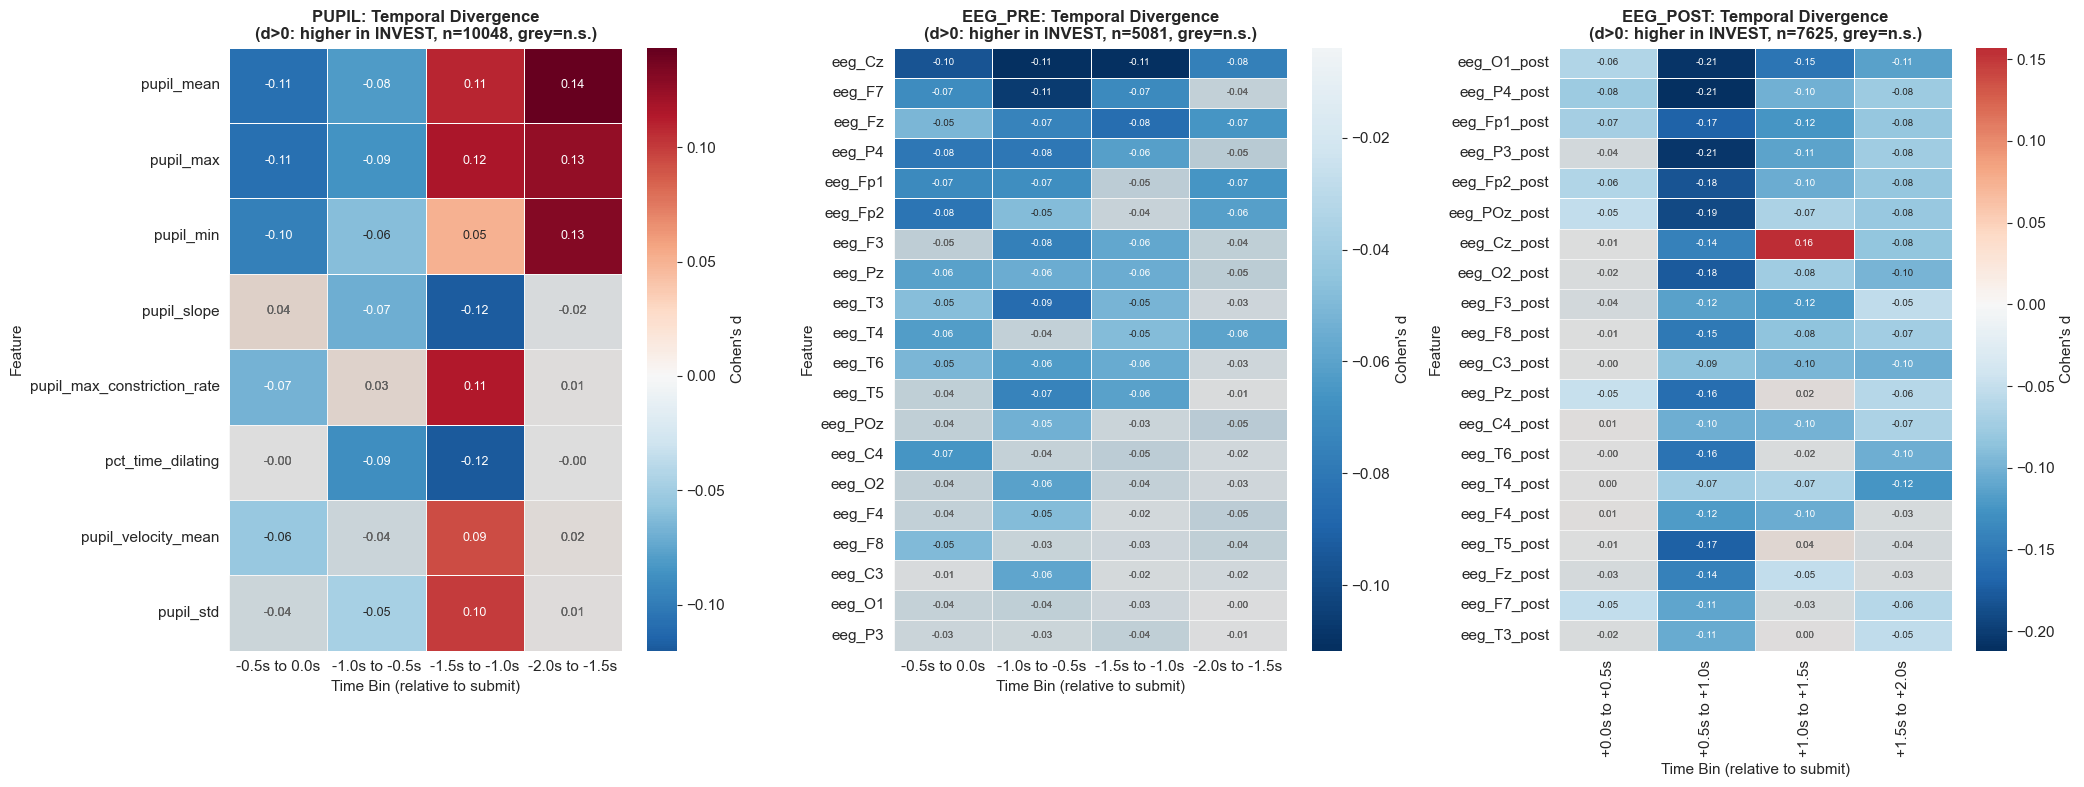


Saved: ../../data/results/main/statistical_analyses/temporal_dynamics/temporal_divergence_heatmaps.png


In [32]:
# Heatmaps by modality - separate PRE and POST
modalities_with_data = [m for m in all_temporal_df['modality'].unique() 
                        if len(all_temporal_df[all_temporal_df['modality'] == m]) > 0]
n_modalities = len(modalities_with_data)

if n_modalities > 0:
    # Determine layout
    n_cols = min(3, n_modalities)
    n_rows = (n_modalities + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, max(8, 6 * n_rows)))
    
    if n_modalities == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, modality in enumerate(modalities_with_data):
        row, col = idx // n_cols, idx % n_cols
        ax = axes[row, col]
        mod_df = all_temporal_df[all_temporal_df['modality'] == modality]
        
        # Pivot for Cohen's d values
        pivot = mod_df.pivot(index='feature', columns='time_label', values='cohens_d')
        
        # Pivot for significance (True = significant)
        pivot_sig = mod_df.pivot(index='feature', columns='time_label', values='significant')
        
        # Sort by average absolute effect
        pivot['avg'] = pivot.abs().mean(axis=1)
        sort_order = pivot.sort_values('avg', ascending=False).index
        pivot = pivot.loc[sort_order].drop('avg', axis=1)
        pivot_sig = pivot_sig.loc[sort_order]
        
        # Adjust annotation size based on number of features
        annot_size = 7 if len(pivot) > 15 else 9
        
        # Create custom colormap with grey for non-significant
        # First plot the heatmap normally
        sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                    cbar_kws={'label': "Cohen's d"}, ax=ax, linewidths=0.5,
                    annot_kws={'size': annot_size})
        
        # Grey out non-significant cells by overlaying rectangles
        for i, feature in enumerate(pivot.index):
            for j, time_label in enumerate(pivot.columns):
                if not pivot_sig.loc[feature, time_label]:
                    # Add grey rectangle over non-significant cells
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, 
                                               facecolor='lightgrey', alpha=0.7,
                                               edgecolor='white', linewidth=0.5))
                    # Re-add the annotation in grey
                    val = pivot.loc[feature, time_label]
                    if not pd.isna(val):
                        ax.text(j + 0.5, i + 0.5, f'{val:.2f}', 
                               ha='center', va='center', fontsize=annot_size,
                               color='dimgrey')
        
        ax.set_xlabel('Time Bin (relative to submit)')
        ax.set_ylabel('Feature')
        
        n_trials = mod_df['n_invest'].iloc[0] + mod_df['n_keep'].iloc[0] if len(mod_df) > 0 else 0
        ax.set_title(f'{modality.upper()}: Temporal Divergence\n(d>0: higher in INVEST, n={n_trials}, grey=n.s.)', 
                     fontsize=12, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(n_modalities, n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'temporal_divergence_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'temporal_divergence_heatmaps.png'}")

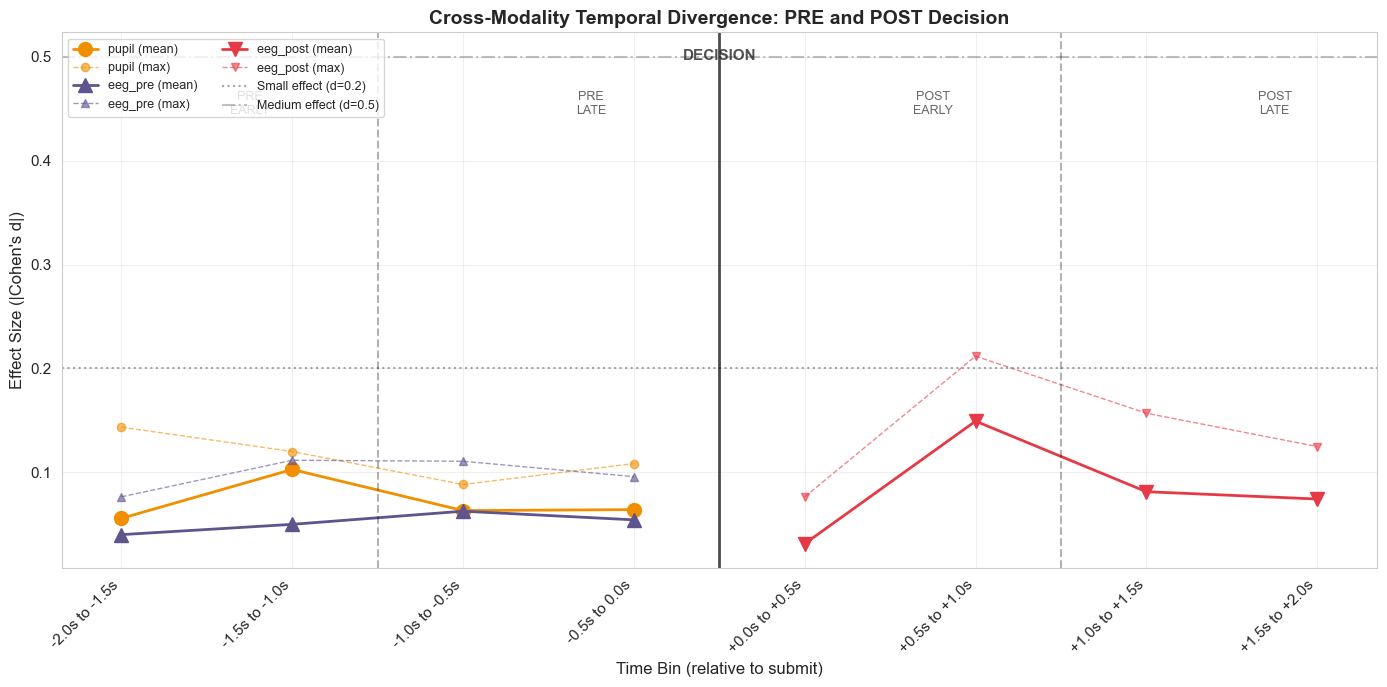


Saved: ../../data/results/main/statistical_analyses/temporal_dynamics/cross_modality_temporal_alignment.png


In [33]:
# Cross-modality comparison: effect size over time
if len(alignment_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    colors = {'pupil': '#F18F01', 'gaze': '#2E86AB', 'eeg_pre': '#5E548E', 'eeg_post': '#E63946'}
    markers = {'pupil': 'o', 'gaze': 's', 'eeg_pre': '^', 'eeg_post': 'v'}
    
    # Plot each modality
    for modality in alignment_df['modality'].unique():
        mod_data = alignment_df[alignment_df['modality'] == modality].copy()
        
        # Create a combined index for plotting
        if 'post' in modality.lower():
            # POST bins: add offset to separate from PRE
            x_offset = len(PRE_TIME_BINS)
        else:
            x_offset = 0
        
        x = mod_data['bin_idx'].values + x_offset
        y_mean = mod_data['mean_abs_d'].values
        y_max = mod_data['max_abs_d'].values
        
        color = colors.get(modality, 'gray')
        marker = markers.get(modality, 'o')
        
        ax.plot(x, y_mean, marker=marker, linewidth=2, markersize=10,
                label=f'{modality} (mean)', color=color)
        ax.plot(x, y_max, marker=marker, linewidth=1, markersize=6,
                linestyle='--', alpha=0.6, label=f'{modality} (max)', color=color)
    
    ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.7, label='Small effect (d=0.2)')
    ax.axhline(y=0.5, color='gray', linestyle='-.', alpha=0.5, label='Medium effect (d=0.5)')
    
    # Add vertical line at decision point (between PRE and POST)
    ax.axvline(x=len(PRE_TIME_BINS) - 0.5, color='black', linestyle='-', linewidth=2, alpha=0.7)
    ax.text(len(PRE_TIME_BINS) - 0.5, ax.get_ylim()[1]*0.95, 'DECISION', ha='center', fontsize=11, 
            fontweight='bold', alpha=0.8)
    
    # Add early/late annotations for PRE
    if len(PRE_TIME_BINS) >= 4:
        ax.axvline(x=1.5, color='black', linestyle='--', alpha=0.3)
        ax.text(0.75, ax.get_ylim()[1]*0.85, 'PRE\nEARLY', ha='center', fontsize=9, alpha=0.7)
        ax.text(2.75, ax.get_ylim()[1]*0.85, 'PRE\nLATE', ha='center', fontsize=9, alpha=0.7)
    
    # Add early/late annotations for POST
    if HAS_EEG_POST and len(POST_TIME_BINS) >= 4:
        post_offset = len(PRE_TIME_BINS)
        ax.axvline(x=post_offset + 1.5, color='black', linestyle='--', alpha=0.3)
        ax.text(post_offset + 0.75, ax.get_ylim()[1]*0.85, 'POST\nEARLY', ha='center', fontsize=9, alpha=0.7)
        ax.text(post_offset + 2.75, ax.get_ylim()[1]*0.85, 'POST\nLATE', ha='center', fontsize=9, alpha=0.7)
    
    # Set x-axis labels
    all_labels = PRE_BIN_LABELS + (POST_BIN_LABELS if HAS_EEG_POST else [])
    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, rotation=45, ha='right')
    
    ax.set_xlabel('Time Bin (relative to submit)', fontsize=12)
    ax.set_ylabel('Effect Size (|Cohen\'s d|)', fontsize=12)
    ax.set_title('Cross-Modality Temporal Divergence: PRE and POST Decision', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cross_modality_temporal_alignment.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'cross_modality_temporal_alignment.png'}")

## 9. Optimal Time Windows

In [34]:
# Find optimal bin for each feature (pooled - for exploration only)
optimal_bins = []

for modality in temporal_df['modality'].unique():
    mod_df = temporal_df[temporal_df['modality'] == modality]
    
    for feature in mod_df['feature'].unique():
        feat_df = mod_df[mod_df['feature'] == feature]
        if len(feat_df) == 0:
            continue
        
        best_row = feat_df.loc[feat_df['abs_cohens_d'].idxmax()]
        optimal_bins.append({
            'modality': modality,
            'feature': feature,
            'optimal_bin': best_row['time_label'],
            'optimal_bin_idx': int(best_row['bin_idx']),
            'max_d': best_row['cohens_d'],
            'abs_max_d': best_row['abs_cohens_d']
        })

optimal_df = pd.DataFrame(optimal_bins).sort_values('abs_max_d', ascending=False)

print("\n" + "="*80)
print("OPTIMAL TIME BINS BY FEATURE (pooled, for exploration)")
print("="*80)
print(optimal_df.to_string(index=False))

# Summary: which bins are most commonly optimal
print("\n" + "="*50)
print("MOST COMMON OPTIMAL BINS")
print("="*50)
bin_counts = optimal_df['optimal_bin'].value_counts()
for bin_label, count in bin_counts.items():
    print(f"  {bin_label}: {count} features ({100*count/len(optimal_df):.1f}%)")


OPTIMAL TIME BINS BY FEATURE (pooled, for exploration)
modality                     feature    optimal_bin  optimal_bin_idx     max_d  abs_max_d
   pupil                  pupil_mean -2.0s to -1.5s                0  0.143552   0.143552
   pupil                   pupil_min -2.0s to -1.5s                0  0.131695   0.131695
   pupil                   pupil_max -2.0s to -1.5s                0  0.125890   0.125890
   pupil           pct_time_dilating -1.5s to -1.0s                1 -0.120088   0.120088
   pupil                 pupil_slope -1.5s to -1.0s                1 -0.118061   0.118061
   pupil pupil_max_constriction_rate -1.5s to -1.0s                1  0.113801   0.113801
 eeg_pre                      eeg_Cz -1.5s to -1.0s                1 -0.111706   0.111706
 eeg_pre                      eeg_F7 -1.0s to -0.5s                2 -0.106891   0.106891
   pupil                   pupil_std -1.5s to -1.0s                1  0.099477   0.099477
   pupil         pupil_velocity_mean -1.5s t

## 10. Timing-Informed Classification (Q3)

Test whether selecting features from their optimal time bins improves accuracy over full-window averaging.

**Method**: LOSO cross-validation with train-only bin selection (no leakage).

In [35]:
# Prepare data for fusion comparison
print("\nPreparing data for fusion comparison...")

# Create composite trial_id to match merged_df format
df['composite_trial_id'] = df['trial_id'].astype(str) + '_' + df['subject_id'].astype(str)

# Merge with behavior and gaze
aligned_merged = df.merge(
    merged_df[['trial_id', 'subject_id'] + behavior_cols + gaze_cols],
    left_on=['composite_trial_id', 'subject_id'],
    right_on=['trial_id', 'subject_id'],
    how='inner',
    suffixes=('', '_merged')
)

print(f"Merged dataset: {len(aligned_merged)} trials")

# Prepare arrays
X_behavior = SimpleImputer(strategy='mean').fit_transform(aligned_merged[behavior_cols])
X_gaze = SimpleImputer(strategy='mean').fit_transform(aligned_merged[gaze_cols])
y = aligned_merged['outcome'].values
subjects = aligned_merged['subject_id'].values

# Prepare bin_df for train-only bin selection
bin_df = aligned_merged.reset_index(drop=True)

print(f"\nFeature shapes:")
print(f"  Behavior: {X_behavior.shape}")
print(f"  Gaze: {X_gaze.shape}")
print(f"  Subjects: {len(np.unique(subjects))}")


Preparing data for fusion comparison...
Merged dataset: 10048 trials

Feature shapes:
  Behavior: (10048, 11)
  Gaze: (10048, 20)
  Subjects: 102


In [36]:
# Time-aligned fusion: optimal pupil bin per feature chosen on training subjects only
print("\nRunning time-aligned late fusion (train-only bin selection per fold)...")
modality_names = ['Physio (Time-Aligned)', 'Behavior', 'Gaze']

results_aligned = weighted_late_fusion_train_optimal_bins(
    bin_df,
    PUPIL_FEATURES,
    n_bins=len(TIME_BINS),
    X_behavior=X_behavior,
    X_gaze=X_gaze,
    y=y,
    subjects=subjects,
    modality_names=modality_names,
    fusion_method='weighted',
)

print(f"\nTIME-ALIGNED RESULTS:")
print(f"  Accuracy: {results_aligned['accuracy_mean']:.4f} +/- {results_aligned['accuracy_sem']:.4f}")
print(f"  Weights: {dict(zip(modality_names, [f'{w:.3f}' for w in results_aligned['weights']]))}")


Running time-aligned late fusion (train-only bin selection per fold)...

TIME-ALIGNED RESULTS:
  Accuracy: 0.7394 +/- 0.0132
  Weights: {'Physio (Time-Aligned)': '0.008', 'Behavior': '0.685', 'Gaze': '0.307'}


In [37]:
# Run baseline (full window) for comparison
print("\nRunning baseline (full window) late fusion...")

# Get full-window physiology features
baseline_merged = merged_df[merged_df['trial_id'].isin(aligned_merged['composite_trial_id'])].copy()
baseline_merged = baseline_merged.reset_index(drop=True)

# Ensure same order as aligned_merged
baseline_merged = baseline_merged.set_index('trial_id').loc[aligned_merged['composite_trial_id']].reset_index()

X_physio_baseline = SimpleImputer(strategy='mean').fit_transform(baseline_merged[physio_cols])
X_behavior_baseline = SimpleImputer(strategy='mean').fit_transform(baseline_merged[behavior_cols])
X_gaze_baseline = SimpleImputer(strategy='mean').fit_transform(baseline_merged[gaze_cols])
y_baseline = baseline_merged['outcome'].values
subjects_baseline = baseline_merged['subject_id'].values

X_modalities_baseline = [X_physio_baseline, X_behavior_baseline, X_gaze_baseline]
modality_names_baseline = ['Physio (Full Window)', 'Behavior', 'Gaze']

results_baseline = weighted_late_fusion(
    X_modalities_baseline, y_baseline, subjects_baseline, modality_names_baseline, fusion_method='weighted'
)

print(f"\nBASELINE (FULL WINDOW) RESULTS:")
print(f"  Accuracy: {results_baseline['accuracy_mean']:.4f} +/- {results_baseline['accuracy_sem']:.4f}")
print(f"  Weights: {dict(zip(modality_names_baseline, [f'{w:.3f}' for w in results_baseline['weights']]))}")


Running baseline (full window) late fusion...

BASELINE (FULL WINDOW) RESULTS:
  Accuracy: 0.7408 +/- 0.0134
  Weights: {'Physio (Full Window)': '0.010', 'Behavior': '0.684', 'Gaze': '0.305'}


In [38]:
# Compare results
print("\n" + "="*70)
print("Q3 ANSWER: TIMING-INFORMED vs FULL WINDOW CLASSIFICATION")
print("="*70)

acc_diff = results_aligned['accuracy_mean'] - results_baseline['accuracy_mean']
pct_diff = 100 * acc_diff / results_baseline['accuracy_mean']

comparison = pd.DataFrame([
    {'Method': 'Full window physio', 
     'Accuracy': f"{results_baseline['accuracy_mean']:.4f}",
     'SEM': f"{results_baseline['accuracy_sem']:.4f}",
     'Physio Weight': f"{results_baseline['weights'][0]:.3f}"},
    {'Method': 'Time-aligned physio (train-only bin selection)', 
     'Accuracy': f"{results_aligned['accuracy_mean']:.4f}",
     'SEM': f"{results_aligned['accuracy_sem']:.4f}",
     'Physio Weight': f"{results_aligned['weights'][0]:.3f}"}
])
print(comparison.to_string(index=False))

print(f"\nAccuracy difference: {acc_diff:+.4f} ({pct_diff:+.2f}%)")

# Statistical comparison (paired t-test on subject accuracies)
if len(results_aligned['accuracy_per_subject']) == len(results_baseline['accuracy_per_subject']):
    t_stat, p_val = stats.ttest_rel(
        results_aligned['accuracy_per_subject'],
        results_baseline['accuracy_per_subject']
    )
    print(f"Paired t-test: t={t_stat:.3f}, p={p_val:.4f}")

# Interpretation
print("\n" + "-"*50)
print("INTERPRETATION:")
print("-"*50)

if abs(acc_diff) < 0.005:
    print("Time-aligned selection ~= full-window averaging.")
    print("This is common when:")
    print("  1. Behavior dominates fusion (physio weight is low)")
    print("  2. Signal is consistent across time bins")
    print("  3. Train-selected bins often match across folds")
elif acc_diff > 0.005:
    print("Time-aligned selection IMPROVES accuracy.")
    print("Focusing on high-divergence time bins helps classification.")
else:
    print("Time-aligned selection DECREASES accuracy.")
    print("Full-window averaging may provide more stable signal.")


Q3 ANSWER: TIMING-INFORMED vs FULL WINDOW CLASSIFICATION
                                        Method Accuracy    SEM Physio Weight
                            Full window physio   0.7408 0.0134         0.010
Time-aligned physio (train-only bin selection)   0.7394 0.0132         0.008

Accuracy difference: -0.0014 (-0.19%)
Paired t-test: t=-1.129, p=0.2615

--------------------------------------------------
INTERPRETATION:
--------------------------------------------------
Time-aligned selection ~= full-window averaging.
This is common when:
  1. Behavior dominates fusion (physio weight is low)
  2. Signal is consistent across time bins
  3. Train-selected bins often match across folds


## 10.5 Per-Bin Late Fusion Classification (Q4)

This section runs the late fusion classification model on each individual time bin to identify which temporal windows carry the most predictive information for distinguishing INVEST vs KEEP decisions.

In [39]:
print("="*70)
print("PER-BIN LATE FUSION CLASSIFICATION")
print("="*70)
print("\nRunning late fusion on each individual time bin to find optimal windows...")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

def run_per_bin_classification(df_subset, feature_list, time_bins, bin_labels, 
                               X_behavior, X_gaze, y, subjects, bin_suffix=''):
    """
    Run late fusion classification on each individual time bin.
    
    Returns a DataFrame with accuracy for each bin.
    """
    results = []
    logo = LeaveOneGroupOut()
    
    for bin_idx in range(len(time_bins)):
        # Get features for this bin
        bin_cols = [f'{feat}{bin_suffix}_bin{bin_idx}' for feat in feature_list]
        available_cols = [c for c in bin_cols if c in df_subset.columns]
        
        if len(available_cols) == 0:
            continue
        
        X_physio_bin = df_subset[available_cols].values
        
        # Impute and scale
        X_physio_bin = SimpleImputer(strategy='mean').fit_transform(X_physio_bin)
        
        # Run LOSO cross-validation with weighted late fusion
        modalities = [X_physio_bin, X_behavior, X_gaze]
        modality_names = ['Physio', 'Behavior', 'Gaze']
        
        try:
            fusion_results = weighted_late_fusion(
                modalities, y, subjects, modality_names, fusion_method='weighted'
            )
            
            results.append({
                'bin_idx': bin_idx,
                'time_label': bin_labels[bin_idx],
                'accuracy': fusion_results['accuracy_mean'],
                'accuracy_sem': fusion_results['accuracy_sem'],
                'physio_weight': fusion_results['weights'][0],
                'behavior_weight': fusion_results['weights'][1],
                'gaze_weight': fusion_results['weights'][2],
                'n_features': len(available_cols)
            })
        except Exception as e:
            print(f"  Warning: Bin {bin_idx} ({bin_labels[bin_idx]}) failed: {e}")
            continue
    
    return pd.DataFrame(results)

# Prepare aligned data for classification
# Use the merged dataset from earlier
print(f"\nUsing aligned dataset with {len(aligned_merged)} trials")

# PRE-decision bins: Pupil features
print("\n--- PRE-DECISION PUPIL BINS ---")
pre_pupil_results = run_per_bin_classification(
    aligned_merged, PUPIL_FEATURES, PRE_TIME_BINS, PRE_BIN_LABELS,
    X_behavior, X_gaze, y, subjects
)

if len(pre_pupil_results) > 0:
    print(pre_pupil_results.to_string(index=False))
    best_pre = pre_pupil_results.loc[pre_pupil_results['accuracy'].idxmax()]
    print(f"\nBest PRE bin: {best_pre['time_label']} (acc={best_pre['accuracy']:.4f})")

PER-BIN LATE FUSION CLASSIFICATION

Running late fusion on each individual time bin to find optimal windows...

Using aligned dataset with 10048 trials

--- PRE-DECISION PUPIL BINS ---
 bin_idx     time_label  accuracy  accuracy_sem  physio_weight  behavior_weight  gaze_weight  n_features
       0 -2.0s to -1.5s  0.741467      0.013147       0.010831         0.686046     0.303123           8
       1 -1.5s to -1.0s  0.740589      0.013151       0.004502         0.683930     0.311567           8
       2 -1.0s to -0.5s  0.741814      0.013116       0.006341         0.681888     0.311770           8
       3  -0.5s to 0.0s  0.740641      0.013084       0.007254         0.683387     0.309359           8

Best PRE bin: -1.0s to -0.5s (acc=0.7418)


In [40]:
# Per-bin classification with EEG (PRE and POST)
print("\n" + "="*70)
print("EEG PER-BIN CLASSIFICATION")
print("="*70)

# Get EEG-aligned subset
if HAS_EEG_PRE or HAS_EEG_POST:
    # Filter to trials with EEG
    eeg_aligned = aligned_merged[aligned_merged['has_eeg_pre'] == True].copy() if 'has_eeg_pre' in aligned_merged.columns else aligned_merged[aligned_merged['has_eeg'] == True].copy()
    
    if len(eeg_aligned) > 0:
        X_behavior_eeg = SimpleImputer(strategy='mean').fit_transform(eeg_aligned[behavior_cols])
        X_gaze_eeg = SimpleImputer(strategy='mean').fit_transform(eeg_aligned[gaze_cols])
        y_eeg = eeg_aligned['outcome'].values
        subjects_eeg = eeg_aligned['subject_id'].values
        
        print(f"EEG-aligned subset: {len(eeg_aligned)} trials, {len(np.unique(subjects_eeg))} subjects")
        
        # PRE-decision EEG bins
        if HAS_EEG_PRE:
            print("\n--- PRE-DECISION EEG BINS ---")
            pre_eeg_results = run_per_bin_classification(
                eeg_aligned, EEG_FEATURES, PRE_TIME_BINS, PRE_BIN_LABELS,
                X_behavior_eeg, X_gaze_eeg, y_eeg, subjects_eeg
            )
            
            if len(pre_eeg_results) > 0:
                print(pre_eeg_results.to_string(index=False))
                best_pre_eeg = pre_eeg_results.loc[pre_eeg_results['accuracy'].idxmax()]
                print(f"\nBest PRE EEG bin: {best_pre_eeg['time_label']} (acc={best_pre_eeg['accuracy']:.4f})")
        
        # POST-decision EEG bins
        if HAS_EEG_POST:
            # Filter to trials with POST EEG
            eeg_post_aligned = eeg_aligned[eeg_aligned['has_eeg_post'] == True].copy() if 'has_eeg_post' in eeg_aligned.columns else eeg_aligned.copy()
            
            if len(eeg_post_aligned) > 0:
                X_behavior_post = SimpleImputer(strategy='mean').fit_transform(eeg_post_aligned[behavior_cols])
                X_gaze_post = SimpleImputer(strategy='mean').fit_transform(eeg_post_aligned[gaze_cols])
                y_post = eeg_post_aligned['outcome'].values
                subjects_post = eeg_post_aligned['subject_id'].values
                
                print(f"\n--- POST-DECISION EEG BINS ---")
                print(f"POST EEG-aligned subset: {len(eeg_post_aligned)} trials")
                
                post_eeg_results = run_per_bin_classification(
                    eeg_post_aligned, EEG_FEATURES_POST, POST_TIME_BINS, POST_BIN_LABELS,
                    X_behavior_post, X_gaze_post, y_post, subjects_post, bin_suffix='_post'
                )
                
                if len(post_eeg_results) > 0:
                    print(post_eeg_results.to_string(index=False))
                    best_post_eeg = post_eeg_results.loc[post_eeg_results['accuracy'].idxmax()]
                    print(f"\nBest POST EEG bin: {best_post_eeg['time_label']} (acc={best_post_eeg['accuracy']:.4f})")
else:
    print("No EEG data available for per-bin classification")


EEG PER-BIN CLASSIFICATION
EEG-aligned subset: 7625 trials, 80 subjects

--- PRE-DECISION EEG BINS ---
 bin_idx     time_label  accuracy  accuracy_sem  physio_weight  behavior_weight  gaze_weight  n_features
       0 -2.0s to -1.5s  0.747302      0.014820       0.001001         0.680627     0.318372          20
       1 -1.5s to -1.0s  0.746796      0.014780       0.001732         0.683421     0.314847          20
       2 -1.0s to -0.5s  0.747131      0.014776       0.007311         0.683963     0.308726          20
       3  -0.5s to 0.0s  0.744836      0.014905       0.008258         0.680552     0.311190          20

Best PRE EEG bin: -2.0s to -1.5s (acc=0.7473)

--- POST-DECISION EEG BINS ---
POST EEG-aligned subset: 7625 trials
 bin_idx     time_label  accuracy  accuracy_sem  physio_weight  behavior_weight  gaze_weight  n_features
       0 +0.0s to +0.5s  0.745484      0.014761       0.007137         0.676537     0.316326          20
       1 +0.5s to +1.0s  0.747353      0.0144


PER-BIN CLASSIFICATION VISUALIZATION


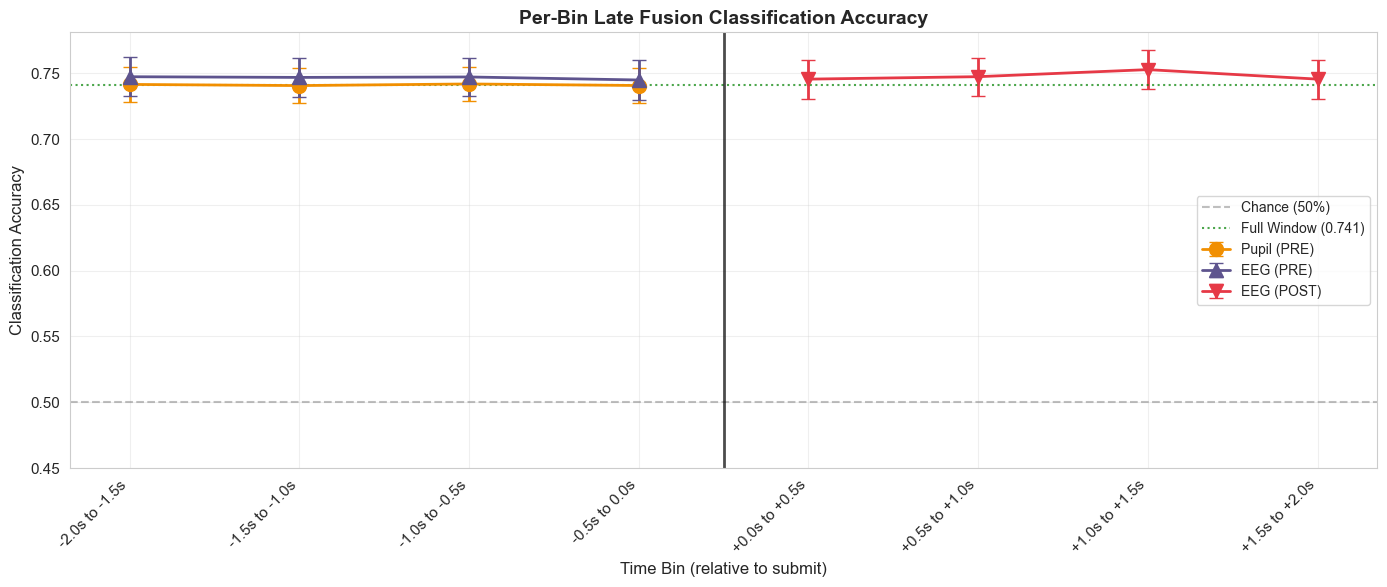


Saved: ../../data/results/main/statistical_analyses/temporal_dynamics/per_bin_classification_accuracy.png

PER-BIN CLASSIFICATION SUMMARY
 bin_idx     time_label  accuracy  accuracy_sem  physio_weight  behavior_weight  gaze_weight  n_features    modality phase
       0 -2.0s to -1.5s  0.741467      0.013147       0.010831         0.686046     0.303123           8 Pupil (PRE)   PRE
       1 -1.5s to -1.0s  0.740589      0.013151       0.004502         0.683930     0.311567           8 Pupil (PRE)   PRE
       2 -1.0s to -0.5s  0.741814      0.013116       0.006341         0.681888     0.311770           8 Pupil (PRE)   PRE
       3  -0.5s to 0.0s  0.740641      0.013084       0.007254         0.683387     0.309359           8 Pupil (PRE)   PRE
       0 -2.0s to -1.5s  0.747302      0.014820       0.001001         0.680627     0.318372          20   EEG (PRE)   PRE
       1 -1.5s to -1.0s  0.746796      0.014780       0.001732         0.683421     0.314847          20   EEG (PRE)   PRE


In [41]:
# Visualize per-bin classification accuracy
print("\n" + "="*70)
print("PER-BIN CLASSIFICATION VISUALIZATION")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 6))

# Combine all results
all_bin_results = []

if len(pre_pupil_results) > 0:
    pre_pupil_results['modality'] = 'Pupil (PRE)'
    pre_pupil_results['phase'] = 'PRE'
    all_bin_results.append(pre_pupil_results)

if HAS_EEG_PRE and 'pre_eeg_results' in dir() and len(pre_eeg_results) > 0:
    pre_eeg_results['modality'] = 'EEG (PRE)'
    pre_eeg_results['phase'] = 'PRE'
    all_bin_results.append(pre_eeg_results)

if HAS_EEG_POST and 'post_eeg_results' in dir() and len(post_eeg_results) > 0:
    post_eeg_results['modality'] = 'EEG (POST)'
    post_eeg_results['phase'] = 'POST'
    all_bin_results.append(post_eeg_results)

if len(all_bin_results) > 0:
    combined_results = pd.concat(all_bin_results, ignore_index=True)
    
    colors = {'Pupil (PRE)': '#F18F01', 'EEG (PRE)': '#5E548E', 'EEG (POST)': '#E63946'}
    markers = {'Pupil (PRE)': 'o', 'EEG (PRE)': '^', 'EEG (POST)': 'v'}
    
    for modality in combined_results['modality'].unique():
        mod_data = combined_results[combined_results['modality'] == modality]
        
        # Adjust x position for POST bins
        if 'POST' in modality:
            x = mod_data['bin_idx'].values + len(PRE_TIME_BINS)
        else:
            x = mod_data['bin_idx'].values
        
        color = colors.get(modality, 'gray')
        marker = markers.get(modality, 'o')
        
        ax.errorbar(x, mod_data['accuracy'].values, yerr=mod_data['accuracy_sem'].values,
                   marker=marker, linewidth=2, markersize=10, capsize=5,
                   label=modality, color=color)
    
    # Reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (50%)')
    ax.axhline(y=results_baseline['accuracy_mean'], color='green', linestyle=':', 
               alpha=0.7, label=f'Full Window ({results_baseline["accuracy_mean"]:.3f})')
    
    # Decision point
    ax.axvline(x=len(PRE_TIME_BINS) - 0.5, color='black', linestyle='-', linewidth=2, alpha=0.7)
    
    # Labels
    all_labels = PRE_BIN_LABELS + (POST_BIN_LABELS if HAS_EEG_POST else [])
    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, rotation=45, ha='right')
    
    ax.set_xlabel('Time Bin (relative to submit)', fontsize=12)
    ax.set_ylabel('Classification Accuracy', fontsize=12)
    ax.set_title('Per-Bin Late Fusion Classification Accuracy', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.45, None)  # Start just below chance
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'per_bin_classification_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'per_bin_classification_accuracy.png'}")
    
    # Summary
    print("\n" + "="*50)
    print("PER-BIN CLASSIFICATION SUMMARY")
    print("="*50)
    print(combined_results.to_string(index=False))

## 11. Save Results

In [42]:
# Save all results
all_temporal_df.to_csv(OUTPUT_DIR / 'temporal_divergence_all.csv', index=False)
optimal_df.to_csv(OUTPUT_DIR / 'optimal_time_bins.csv', index=False)
alignment_df.to_csv(OUTPUT_DIR / 'cross_modality_alignment.csv', index=False)

comparison_results = pd.DataFrame([
    {'method': 'full_window', 'accuracy': results_baseline['accuracy_mean'], 
     'sem': results_baseline['accuracy_sem'], 'physio_weight': results_baseline['weights'][0]},
    {'method': 'time_aligned', 'accuracy': results_aligned['accuracy_mean'], 
     'sem': results_aligned['accuracy_sem'], 'physio_weight': results_aligned['weights'][0]}
])
comparison_results.to_csv(OUTPUT_DIR / 'alignment_comparison.csv', index=False)

# Save per-bin classification results
if 'combined_results' in dir() and len(combined_results) > 0:
    combined_results.to_csv(OUTPUT_DIR / 'per_bin_classification_results.csv', index=False)

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f"  - {f.name}")


FILES SAVED
  - alignment_comparison.csv
  - cross_modality_alignment.csv
  - cross_modality_temporal_alignment.png
  - optimal_time_bins.csv
  - per_bin_classification_accuracy.png
  - per_bin_classification_results.csv
  - temporal_divergence_all.csv
  - temporal_divergence_heatmaps.png
  - temporal_evolution_comparison.png
  - temporal_heatmaps.png


## 12. Summary

In [43]:
print("\n" + "="*70)
print("TEMPORAL DYNAMICS ANALYSIS SUMMARY")
print("="*70)

print("\n** Q1: SIGNAL EMERGENCE **")
for modality in all_temporal_df['modality'].unique():
    mod_df = all_temporal_df[all_temporal_df['modality'] == modality]
    if len(mod_df) == 0:
        continue
    strongest = mod_df.loc[mod_df['abs_cohens_d'].idxmax()]
    n_sig = mod_df['significant'].sum()
    print(f"  {modality.upper()}:")
    print(f"    Strongest: {strongest['feature']} at {strongest['time_label']} (d={strongest['cohens_d']:.3f})")
    print(f"    Significant effects: {n_sig}/{len(mod_df)}")

print("\n** Q2: CROSS-MODALITY ALIGNMENT **")
if len(peak_bins) >= 2:
    for mod, peak_label in sorted(peak_bins.items()):
        print(f"  {mod.upper()} peaks at: {peak_label}")
    unique_peaks = set(peak_bins.values())
    if len(unique_peaks) == 1:
        print("  -> SYNCHRONIZED divergence")
    else:
        print("  -> SEQUENTIAL divergence")

print("\n** Q3: TIMING-INFORMED CLASSIFICATION **")
print(f"  Full window:   {results_baseline['accuracy_mean']:.4f} +/- {results_baseline['accuracy_sem']:.4f}")
print(f"  Time-aligned:  {results_aligned['accuracy_mean']:.4f} +/- {results_aligned['accuracy_sem']:.4f}")
print(f"  Difference:    {acc_diff:+.4f} ({pct_diff:+.2f}%)")

print("\n** Q4: PER-BIN CLASSIFICATION **")
if 'combined_results' in dir() and len(combined_results) > 0:
    for modality in combined_results['modality'].unique():
        mod_data = combined_results[combined_results['modality'] == modality]
        best = mod_data.loc[mod_data['accuracy'].idxmax()]
        print(f"  {modality}:")
        print(f"    Best bin: {best['time_label']} (acc={best['accuracy']:.4f} +/- {best['accuracy_sem']:.4f})")
else:
    print("  No per-bin classification results available")

print("\n** DATA SUMMARY **")
print(f"  Total trials: {len(df)}")
print(f"  Trials with PRE EEG: {df['has_eeg_pre'].sum() if 'has_eeg_pre' in df.columns else df['has_eeg'].sum()}")
print(f"  Trials with POST EEG: {df['has_eeg_post'].sum() if 'has_eeg_post' in df.columns else 0}")
print(f"  Trials with gaze: {df['has_gaze'].sum()}")
print(f"  Subjects: {df['subject_id'].nunique()}")

print(f"\n" + "="*70)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


TEMPORAL DYNAMICS ANALYSIS SUMMARY

** Q1: SIGNAL EMERGENCE **
  PUPIL:
    Strongest: pupil_mean at -2.0s to -1.5s (d=0.144)
    Significant effects: 22/32
  EEG_PRE:
    Strongest: eeg_Cz at -1.5s to -1.0s (d=-0.112)
    Significant effects: 42/80
  EEG_POST:
    Strongest: eeg_P4_post at +0.5s to +1.0s (d=-0.212)
    Significant effects: 59/80

** Q2: CROSS-MODALITY ALIGNMENT **
  EEG_POST peaks at: +0.5s to +1.0s
  EEG_PRE peaks at: -1.0s to -0.5s
  PUPIL peaks at: -1.5s to -1.0s
  -> SEQUENTIAL divergence

** Q3: TIMING-INFORMED CLASSIFICATION **
  Full window:   0.7408 +/- 0.0134
  Time-aligned:  0.7394 +/- 0.0132
  Difference:    -0.0014 (-0.19%)

** Q4: PER-BIN CLASSIFICATION **
  Pupil (PRE):
    Best bin: -1.0s to -0.5s (acc=0.7418 +/- 0.0131)
  EEG (PRE):
    Best bin: -2.0s to -1.5s (acc=0.7473 +/- 0.0148)
  EEG (POST):
    Best bin: +1.0s to +1.5s (acc=0.7527 +/- 0.0149)

** DATA SUMMARY **
  Total trials: 10048
  Trials with PRE EEG: 7625
  Trials with POST EEG: 7625
  T